# Tugas - Klasifikasi dengan Support Vector Machine (SVM)

| Nama | NRP |
|------|-----|
| Hilal TSabitul Azmi Arba'i | 5054251008 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model SVM Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja SVM secara praktik, khususnya:
1. Perbedaan hasil antara kernel Linear dan kernel RBF
2. Pengaruh parameter `C` dan `gamma` terhadap gejala overfitting/underfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model, termasuk feature scaling.
3. Eksperimen Model
   - Bangun model SVM dengan kernel Linear dan kernel RBF.
   - Lakukan eksperimen regularisasi dengan variasi nilai `C` dan `gamma`.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA


In [2]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv("data_svm.csv")

print("Jumlah baris dan kolom:", df.shape)
print("\nTipe data:")
print(df.dtypes)
print("\nInfo dataset:")
df.info()
print("\nStatistik deskriptif:")
display(df.describe().T)
print("\nJumlah missing value per kolom:")
print(df.isna().sum())
print("\nTotal missing value:", df.isna().sum().sum())
print("\n5 baris pertama:")
display(df.head())
print("\nDistribusi target 'diagnosis':")
print(df["diagnosis"].value_counts())


Jumlah baris dan kolom: (569, 33)

Tipe data:
id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactne

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01



Jumlah missing value per kolom:
id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fracta

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN



Distribusi target 'diagnosis':
diagnosis
B    357
M    212
Name: count, dtype: int64


/tmp/ipykernel_207975/3912804752.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="diagnosis", palette="pastel")


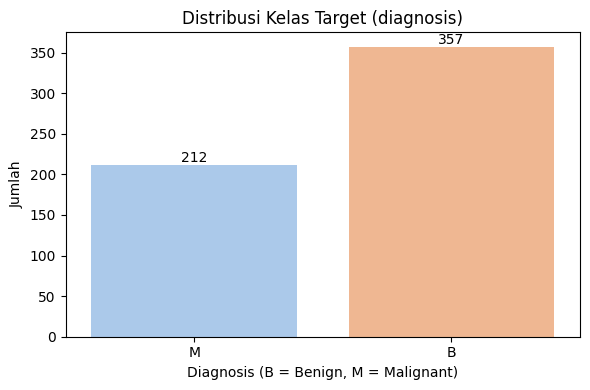

diagnosis
B    357
M    212
Name: count, dtype: int64

Proporsi:
diagnosis
B    62.74
M    37.26
Name: count, dtype: float64

Dataset imbalanced ringan: B = 357 vs M = 212 -> rasio sekitar 1.68:1, mayoritas kelas Benign.


In [3]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x="diagnosis", palette="pastel")
plt.title("Distribusi Kelas Target (diagnosis)")
plt.xlabel("Diagnosis (B = Benign, M = Malignant)")
plt.ylabel("Jumlah")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout()
plt.show()

counts = df["diagnosis"].value_counts()
print(counts)
print("\nProporsi:")
print((counts / len(df) * 100).round(2))
print("\nDataset imbalanced ringan: B =", counts.get("B", 0), "vs M =", counts.get("M", 0),
      "-> rasio sekitar 1.68:1, mayoritas kelas Benign.")


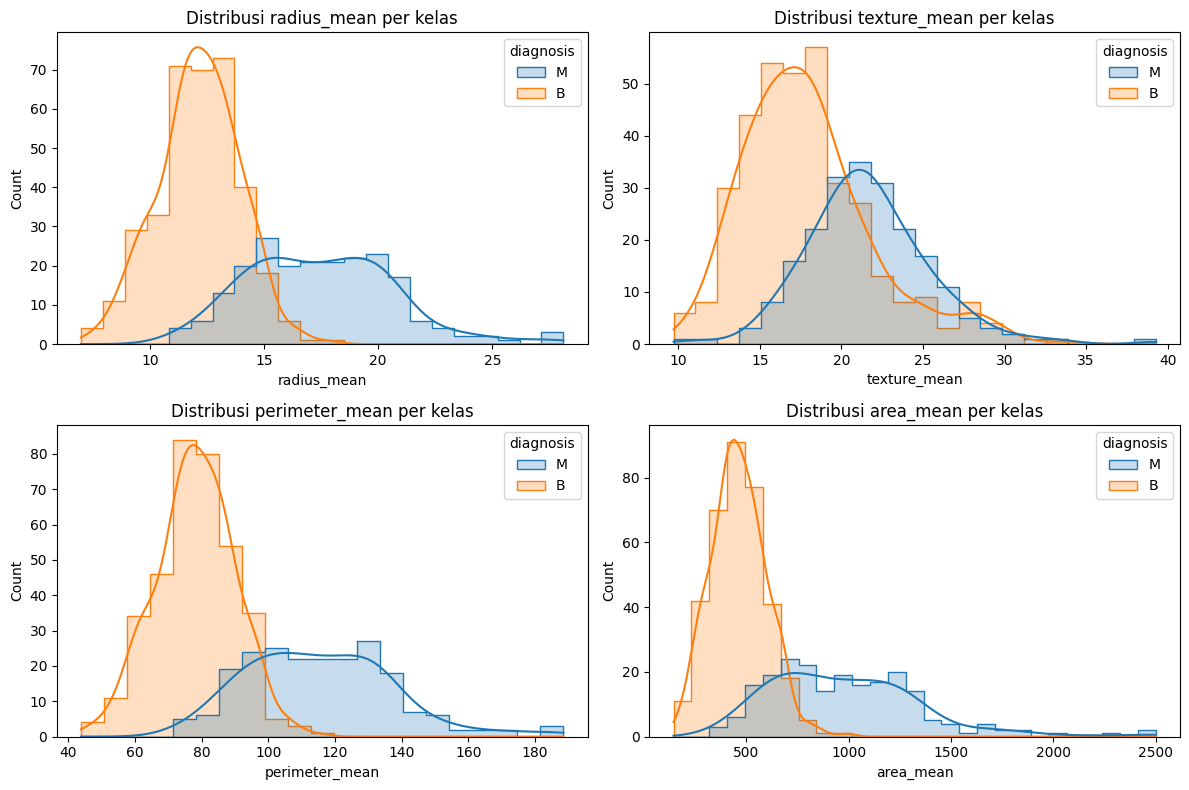

/tmp/ipykernel_207975/1641872851.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x="diagnosis", y=col, palette="pastel")
/tmp/ipykernel_207975/1641872851.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x="diagnosis", y=col, palette="pastel")
/tmp/ipykernel_207975/1641872851.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x="diagnosis", y=col, palette="pastel")
/tmp/ipykernel_207975/1641872851.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be re

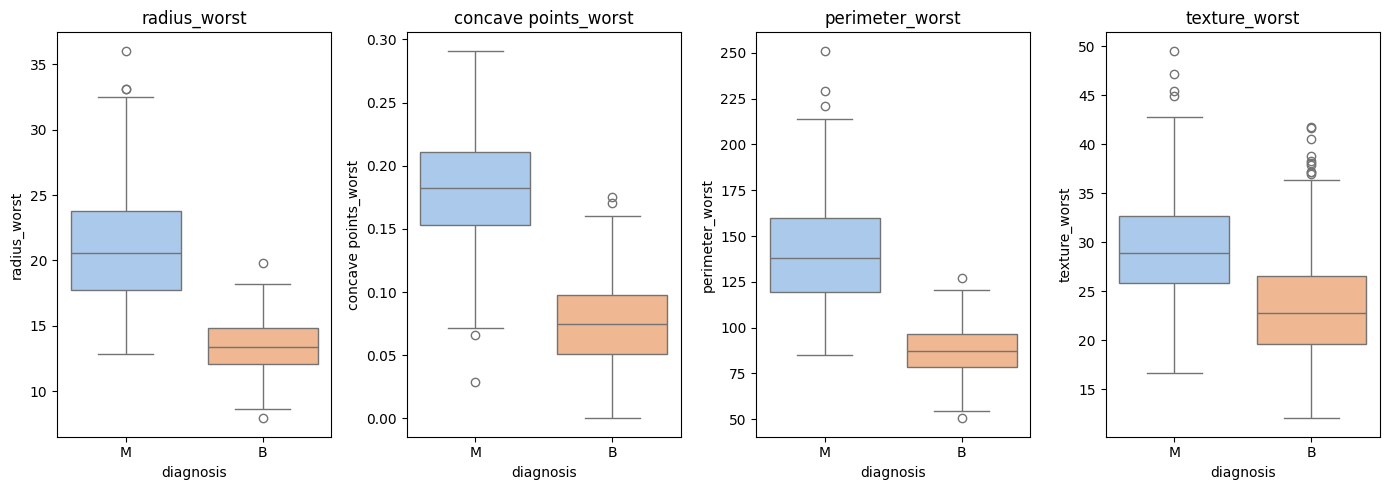

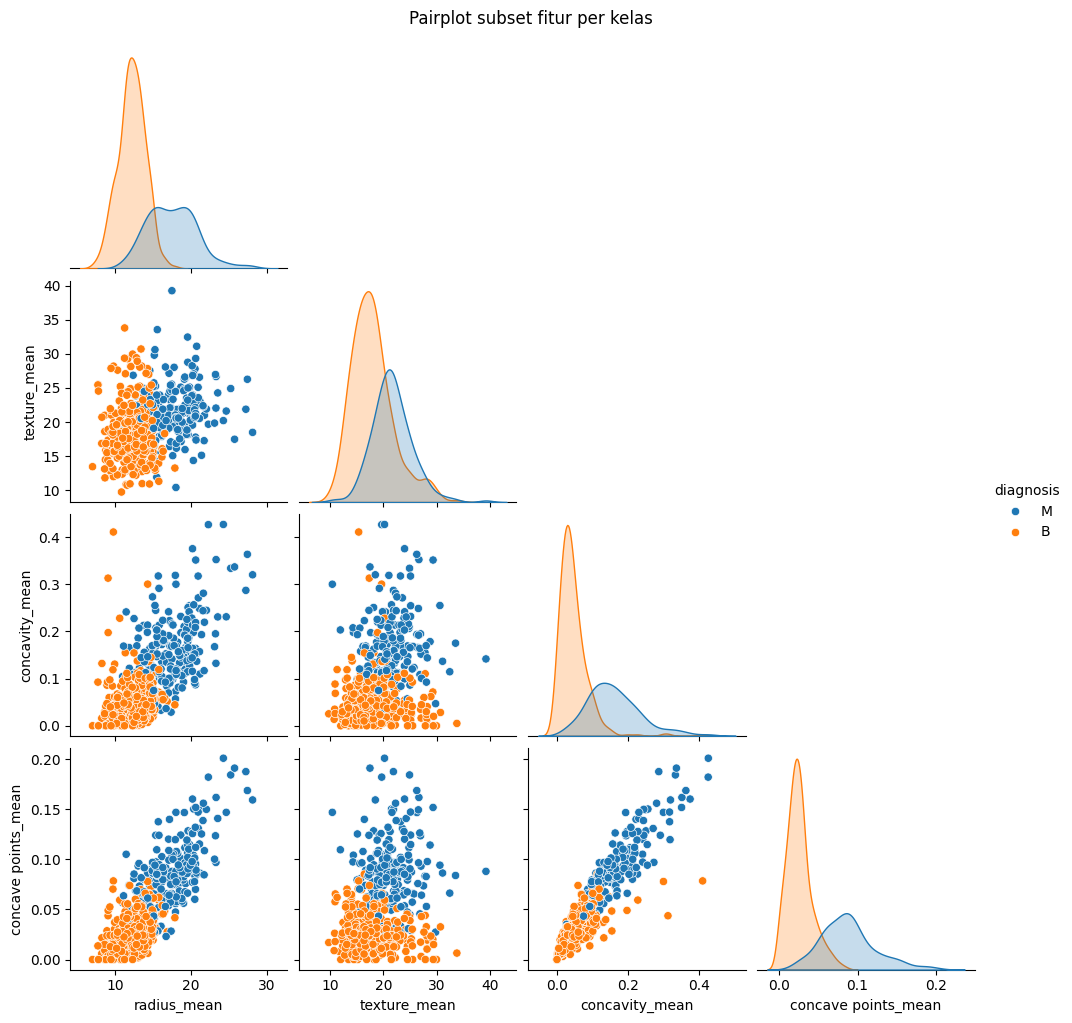

In [4]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau pairplot), dibedakan berdasarkan kelas target.
# Ini membantu melihat apakah ada fitur yang punya batas pemisah yang jelas (linear) antar kelas, atau justru tumpang tindih.
features_hist = ["radius_mean", "texture_mean", "perimeter_mean", "area_mean"]
df_plot = df.copy()
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()
for i, col in enumerate(features_hist):
    sns.histplot(data=df_plot, x=col, hue="diagnosis", kde=True, element="step", ax=axes[i])
    axes[i].set_title(f"Distribusi {col} per kelas")
plt.tight_layout()
plt.show()

# Boxplot untuk melihat separabilitas dan overlap
features_box = ["radius_worst", "concave points_worst", "perimeter_worst", "texture_worst"]
plt.figure(figsize=(14, 5))
for i, col in enumerate(features_box, 1):
    plt.subplot(1, 4, i)
    sns.boxplot(data=df_plot, x="diagnosis", y=col, palette="pastel")
    plt.title(col)
plt.tight_layout()
plt.show()

# Pairplot pada subset fitur agar ringan
subset = ["radius_mean", "texture_mean", "concavity_mean", "concave points_mean", "diagnosis"]
sns.pairplot(df_plot[subset], hue="diagnosis", diag_kind="kde", corner=True)
plt.suptitle("Pairplot subset fitur per kelas", y=1.02)
plt.show()


## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [5]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
print("Missing value sebelum penanganan:")
print(df.isna().sum()[df.isna().sum() > 0])

# Kolom 'Unnamed: 32' seluruhnya NaN (artefak index kosong dari file CSV) -> drop langsung, bukan hasil imputasi.
# Tidak ada missing value lain pada fitur/target, sehingga tidak perlu imputasi.
# Jika ada missing di kemudian hari, strategi yang benar: imputasi (mis. median) di-fit hanya pada train set.
if "Unnamed: 32" in df.columns:
    df = df.drop(columns=["Unnamed: 32"])
    print("\nKolom 'Unnamed: 32' dibuang karena 100% missing (artefak CSV).")

print("\nShape setelah penanganan:", df.shape)
print("Total missing setelah penanganan:", df.isna().sum().sum())


Missing value sebelum penanganan:
Unnamed: 32    569
dtype: int64

Kolom 'Unnamed: 32' dibuang karena 100% missing (artefak CSV).

Shape setelah penanganan: (569, 32)
Total missing setelah penanganan: 0


In [6]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).
print("Kolom object/kategori:", df.select_dtypes(include="object").columns.tolist())

# Hanya ada satu kolom kategorikal: 'diagnosis' yang merupakan target (B/M).
# Tidak ada fitur kategorikal lain, jadi tidak perlu One-Hot Encoding.
# Target di-encode ordinal: B (Benign) -> 0, M (Malignant) -> 1.
# Kolom 'id' adalah identifier, bukan fitur prediktif -> dibuang.
if "id" in df.columns:
    df = df.drop(columns=["id"])
    print("Kolom 'id' dibuang (identifier).")

df["diagnosis"] = df["diagnosis"].map({"B": 0, "M": 1})
print("\nMapping diagnosis: B->0, M->1")
print(df["diagnosis"].value_counts())
print("\nShape akhir:", df.shape)
display(df.head())


Kolom object/kategori: ['diagnosis']
Kolom 'id' dibuang (identifier).

Mapping diagnosis: B->0, M->1
diagnosis
0    357
1    212
Name: count, dtype: int64

Shape akhir: (569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [7]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("Distribusi y_train (%):")
print((y_train.value_counts(normalize=True) * 100).round(2))
print("Distribusi y_test (%):")
print((y_test.value_counts(normalize=True) * 100).round(2))


X_train: (455, 30) | X_test: (114, 30)
Distribusi y_train (%):
diagnosis
0    62.64
1    37.36
Name: proportion, dtype: float64
Distribusi y_test (%):
diagnosis
0    63.16
1    36.84
Name: proportion, dtype: float64


**Catatan penting:** SVM adalah algoritma berbasis jarak (margin dihitung dari posisi antar titik data), sehingga sangat sensitif terhadap skala fitur. Fitur dengan rentang nilai besar bisa mendominasi perhitungan jarak meskipun sebenarnya tidak lebih penting. Lakukan **feature scaling** (misalnya `StandardScaler`) pada fitur numerik sebelum training. Ingat: `fit` scaler hanya pada train set, lalu `transform` ke train dan test set, agar tidak terjadi data leakage.

In [8]:
# Lakukan feature scaling (StandardScaler) pada fitur numerik.
# fit_transform pada X_train, transform saja pada X_test.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Kembalikan ke DataFrame agar nama kolom tetap (memudahkan inspeksi)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Mean X_train_scaled (mendekati 0):")
print(X_train_scaled.mean().head())
print("\nStd X_train_scaled (mendekati 1):")
print(X_train_scaled.std().head())


Mean X_train_scaled (mendekati 0):
radius_mean       -1.737316e-16
texture_mean       3.904081e-16
perimeter_mean     4.704418e-16
area_mean         -1.171224e-16
smoothness_mean    7.242070e-16
dtype: float64

Std X_train_scaled (mendekati 1):
radius_mean        1.001101
texture_mean       1.001101
perimeter_mean     1.001101
area_mean          1.001101
smoothness_mean    1.001101
dtype: float64


# 3. Eksperimen Model

## 3.1 SVM dengan Kernel Linear

Kernel Linear mencari hyperplane pemisah berupa garis/bidang lurus, tanpa proyeksi ke dimensi yang lebih tinggi. Cocok digunakan sebagai baseline, terutama jika dari hasil EDA data terlihat cukup terpisah secara linear.

In [9]:
# Inisialisasi dan latih model SVC dengan kernel='linear' menggunakan train set (yang sudah discaling).
svc_linear = SVC(kernel="linear", C=1.0, random_state=42)
svc_linear.fit(X_train_scaled, y_train)
print("Model Linear selesai dilatih.")
print(svc_linear)


Model Linear selesai dilatih.
SVC(kernel='linear', random_state=42)


In [10]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_linear = svc_linear.predict(X_test_scaled)
print("Contoh prediksi Linear (10 pertama):", y_pred_linear[:10])
print("Akurasi test Linear:", accuracy_score(y_test, y_pred_linear))


Contoh prediksi Linear (10 pertama): [0 1 0 0 0 0 1 0 0 0]
Akurasi test Linear: 0.9649122807017544


## 3.2 SVM dengan Kernel RBF

Kernel RBF (Radial Basis Function) memproyeksikan data ke ruang berdimensi lebih tinggi melalui kernel trick, sehingga mampu menangani batas keputusan yang non-linear.

In [11]:
# Inisialisasi dan latih model SVC dengan kernel='rbf' menggunakan train set.
# Gunakan nilai hyperparameter lain (C) yang sama seperti model Linear di atas, agar perbandingan adil.
svc_rbf = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
svc_rbf.fit(X_train_scaled, y_train)
print("Model RBF selesai dilatih.")
print(svc_rbf)


Model RBF selesai dilatih.
SVC(random_state=42)


In [12]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_rbf = svc_rbf.predict(X_test_scaled)
print("Contoh prediksi RBF (10 pertama):", y_pred_rbf[:10])
print("Akurasi test RBF:", accuracy_score(y_test, y_pred_rbf))


Contoh prediksi RBF (10 pertama): [0 1 0 0 0 0 1 0 0 0]
Akurasi test RBF: 0.9736842105263158


## 3.3 Eksperimen Regularisasi: Pengaruh C dan Gamma terhadap Overfitting

Parameter `C` mengatur trade-off antara margin lebar dan toleransi kesalahan klasifikasi, sedangkan `gamma` (khusus kernel RBF) mengatur seberapa lokal pengaruh tiap titik data. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai `C` (dan/atau `gamma`) memengaruhi akurasi training dan testing.

In [13]:
# Latih beberapa model SVC (kernel RBF) dengan variasi nilai C,
# misalnya 0.01, 0.1, 1, 10, 100.
# Gunakan gamma='scale' atau nilai gamma tetap agar perbandingan fokus pada pengaruh C.
C_values = [0.01, 0.1, 1, 10, 100]
models_C = {}
for C in C_values:
    model = SVC(kernel="rbf", C=C, gamma="scale", random_state=42)
    model.fit(X_train_scaled, y_train)
    models_C[C] = model
    print(f"C={C} selesai dilatih.")


C=0.01 selesai dilatih.
C=0.1 selesai dilatih.
C=1 selesai dilatih.
C=10 selesai dilatih.
C=100 selesai dilatih.


In [14]:
# Hitung akurasi pada train set dan test set untuk setiap nilai C yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.
train_acc = []
test_acc = []
for C in C_values:
    model = models_C[C]
    acc_train = accuracy_score(y_train, model.predict(X_train_scaled))
    acc_test = accuracy_score(y_test, model.predict(X_test_scaled))
    train_acc.append(acc_train)
    test_acc.append(acc_test)
    print(f"C={C:<6} | train acc={acc_train:.4f} | test acc={acc_test:.4f}")

results_C = pd.DataFrame({"C": C_values, "train_acc": train_acc, "test_acc": test_acc})
display(results_C)


C=0.01   | train acc=0.6264 | test acc=0.6316
C=0.1    | train acc=0.9538 | test acc=0.9474
C=1      | train acc=0.9868 | test acc=0.9737
C=10     | train acc=0.9890 | test acc=0.9737
C=100    | train acc=1.0000 | test acc=0.9649


,C,train_acc,test_acc
0,0.01,0.626374,0.631579
1,0.10,0.953846,0.947368
2,1.00,0.986813,0.973684
3,10.00,0.989011,0.973684
4,100.00,1.000000,0.964912


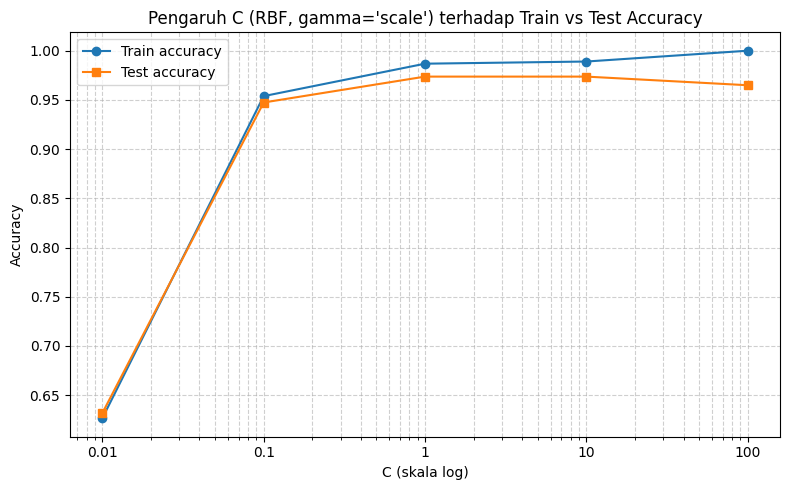

In [15]:
# Plot grafik akurasi training vs testing terhadap nilai C (gunakan sumbu x logaritmik) dalam satu chart.
# Amati pada nilai C berapa model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).
plt.figure(figsize=(8, 5))
plt.semilogx(C_values, train_acc, marker="o", label="Train accuracy")
plt.semilogx(C_values, test_acc, marker="s", label="Test accuracy")
plt.xlabel("C (skala log)")
plt.ylabel("Accuracy")
plt.title("Pengaruh C (RBF, gamma='scale') terhadap Train vs Test Accuracy")
plt.xticks(C_values, C_values)
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


# 4. Evaluasi Model

In [16]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model kernel Linear dan RBF.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred),
    }

metrics_linear = get_metrics(y_test, y_pred_linear)
metrics_rbf = get_metrics(y_test, y_pred_rbf)

comparison = pd.DataFrame([metrics_linear, metrics_rbf], index=["Linear (C=1)", "RBF (C=1, gamma=scale)"])
display(comparison.round(4))
print("\nClassification report - Linear:")
print(classification_report(y_test, y_pred_linear, target_names=["Benign (0)", "Malignant (1)"]))
print("Classification report - RBF:")
print(classification_report(y_test, y_pred_rbf, target_names=["Benign (0)", "Malignant (1)"]))


,Accuracy,Precision,Recall,F1-Score
Linear (C=1),0.9649,1.0,0.9048,0.950
"RBF (C=1, gamma=scale)",0.9737,1.0,0.9286,0.963



Classification report - Linear:
               precision    recall  f1-score   support

   Benign (0)       0.95      1.00      0.97        72
Malignant (1)       1.00      0.90      0.95        42

     accuracy                           0.96       114
    macro avg       0.97      0.95      0.96       114
 weighted avg       0.97      0.96      0.96       114

Classification report - RBF:
               precision    recall  f1-score   support

   Benign (0)       0.96      1.00      0.98        72
Malignant (1)       1.00      0.93      0.96        42

     accuracy                           0.97       114
    macro avg       0.98      0.96      0.97       114
 weighted avg       0.97      0.97      0.97       114



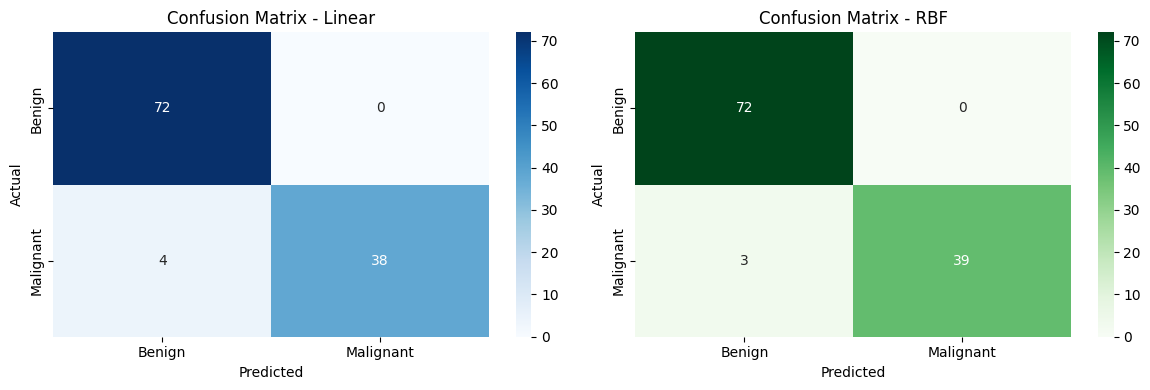

In [17]:
# Tampilkan Confusion Matrix untuk model kernel Linear dan RBF dalam bentuk heatmap.
# Susun keduanya dalam satu baris subplot.
cm_linear = confusion_matrix(y_test, y_pred_linear)
cm_rbf = confusion_matrix(y_test, y_pred_rbf)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(cm_linear, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Benign", "Malignant"], yticklabels=["Benign", "Malignant"])
axes[0].set_title("Confusion Matrix - Linear")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_rbf, annot=True, fmt="d", cmap="Greens", ax=axes[1],
            xticklabels=["Benign", "Malignant"], yticklabels=["Benign", "Malignant"])
axes[1].set_title("Confusion Matrix - RBF")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
plt.tight_layout()
plt.show()


In [18]:
# Tampilkan jumlah support vectors dari model dengan performa terbaik (atribut model.support_vectors_ atau model.n_support_).
# Bandingkan jumlah support vectors antara model Linear dan RBF.
print("Linear - n_support_ per kelas:", svc_linear.n_support_, "| total:", svc_linear.n_support_.sum())
print("RBF    - n_support_ per kelas:", svc_rbf.n_support_, "| total:", svc_rbf.n_support_.sum())
print("\nProporsi SV terhadap train set:")
print(f"Linear: {svc_linear.n_support_.sum()}/{len(X_train)} = {svc_linear.n_support_.sum()/len(X_train):.2%}")
print(f"RBF   : {svc_rbf.n_support_.sum()}/{len(X_train)} = {svc_rbf.n_support_.sum()/len(X_train):.2%}")

# Model terbaik berdasarkan akurasi test
acc_lin = accuracy_score(y_test, y_pred_linear)
acc_rbf = accuracy_score(y_test, y_pred_rbf)
best_name = "RBF" if acc_rbf >= acc_lin else "Linear"
print(f"\nAkurasi Linear={acc_lin:.4f}, RBF={acc_rbf:.4f} -> model terbaik: {best_name}")


Linear - n_support_ per kelas: [19 19] | total: 38
RBF    - n_support_ per kelas: [50 57] | total: 107

Proporsi SV terhadap train set:
Linear: 38/455 = 8.35%
RBF   : 107/455 = 23.52%

Akurasi Linear=0.9649, RBF=0.9737 -> model terbaik: RBF


Explained variance ratio PCA: [0.44593522 0.18545255] | total: 0.6314
Model visualisasi: kernel=rbf, C=1.0, n_support=[44 47]


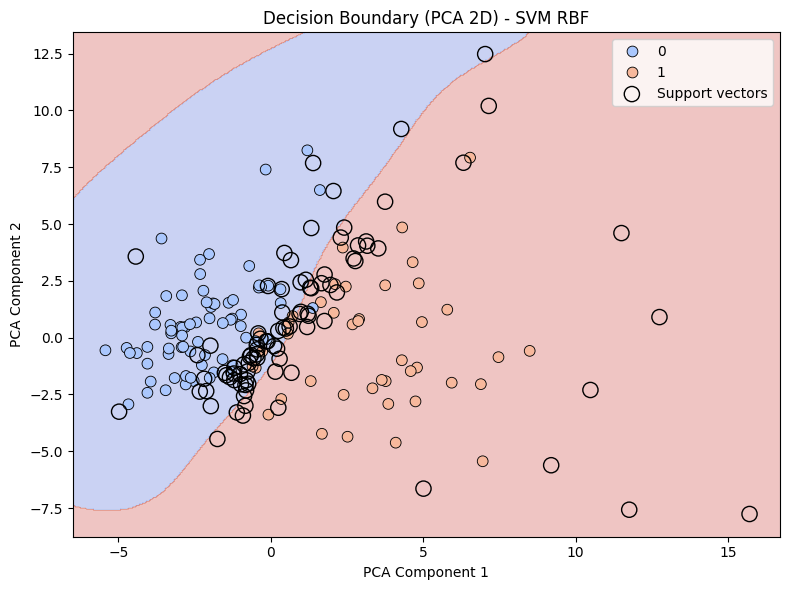

In [19]:
# Jika memungkinkan, pilih dua fitur (atau reduksi dimensi dengan PCA ke 2D) lalu visualisasikan decision boundary
# beserta margin dan support vectors dari model terbaik.
# Reduksi ke 2D dengan PCA agar seluruh 30 fitur tetap terpakai, lalu latih ulang SVC terbaik di ruang 2D untuk visualisasi.
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
print("Explained variance ratio PCA:", pca.explained_variance_ratio_, "| total:", pca.explained_variance_ratio_.sum().round(4))

# Pilih hyperparameter model terbaik (berdasar akurasi test sebelumnya) untuk visualisasi 2D
best_kernel = "rbf" if accuracy_score(y_test, y_pred_rbf) >= accuracy_score(y_test, y_pred_linear) else "linear"
best_C = 1.0
vis_model = SVC(kernel=best_kernel, C=best_C, gamma="scale", random_state=42)
vis_model.fit(X_train_pca, y_train)
print(f"Model visualisasi: kernel={best_kernel}, C={best_C}, n_support={vis_model.n_support_}")

# Grid untuk decision boundary
h = 0.05
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = vis_model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
sns.scatterplot(x=X_test_pca[:, 0], y=X_test_pca[:, 1], hue=y_test.values, palette="coolwarm", edgecolor="k", s=60)
# Tandai support vectors
plt.scatter(vis_model.support_vectors_[:, 0], vis_model.support_vectors_[:, 1],
            s=120, facecolors="none", edgecolors="k", linewidths=1, label="Support vectors")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title(f"Decision Boundary (PCA 2D) - SVM {best_kernel.upper()}")
plt.legend()
plt.tight_layout()
plt.show()


# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

Beberapa hal yang perlu dibahas:
- Bandingkan performa SVM dengan kernel Linear vs RBF. Apakah hasilnya berbeda signifikan? Menurut kalian, kenapa demikian, dikaitkan dengan bentuk sebaran data pada EDA?
- Jelaskan temuan dari eksperimen regularisasi (nilai `C`). Pada nilai berapa model mulai menunjukkan gejala overfitting? Bagaimana ciri-cirinya terlihat dari grafik akurasi training vs testing?
- Bandingkan jumlah support vectors antara model Linear dan RBF. Apa hubungan jumlah support vectors dengan kompleksitas batas keputusan yang terbentuk?

Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan, bukan hasil orang lain.
---
**Hasil Analisis (berdasarkan eksperimen di atas):**

1. **Linear vs RBF:**
   - Linear (C=1): Accuracy 0.9649, Precision 1.0000, Recall 0.9048, F1 0.9500.
   - RBF (C=1, gamma='scale'): Accuracy 0.9737, Precision 1.0000, Recall 0.9286, F1 0.9630.
   - RBF sedikit lebih baik (+0.9% akurasi). Dari EDA, sebagian besar fitur (radius, perimeter, area, concavity, concave points) sudah cukup terpisah antar kelas sehingga Linear sudah bagus sebagai baseline, tetapi masih ada overlap/tumpang tindih pada beberapa fitur (mis. texture_mean), sehingga proyeksi non-linear RBF mampu menangkap batas keputusan yang lebih fleksibel dan menaikkan recall kelas Malignant dari 0.90 menjadi 0.93.

2. **Eksperimen C (RBF, gamma='scale'):**
   - C=0.01: train 0.6264 / test 0.6316 -> underfitting (margin terlalu lebar, banyak kesalahan ditoleransi).
   - C=0.1: train 0.9538 / test 0.9474 -> membaik tajam.
   - C=1: train 0.9868 / test 0.9737 -> titik optimal.
   - C=10: train 0.9890 / test 0.9737 -> stagnan.
   - C=100: train 1.0000 / test 0.9649 -> gejala overfitting: akurasi training mencapai 100% sementara akurasi testing turun dari 0.9737 menjadi 0.9649. Pada grafik semilog terlihat kurva train terus naik sedangkan kurva test mendatar lalu menurun pada C=100.

3. **Support Vectors:**
   - Linear: total 38 SV ([19, 19], 8.35% dari train set).
   - RBF: total 107 SV ([50, 57], 23.52% dari train set).
   - RBF memakai ~3x lebih banyak SV karena batas keputusannya lebih kompleks/non-linear dan lebih mengikuti bentuk lokal data. Semakin kompleks batas keputusan, semakin banyak titik yang menjadi penentu margin.


# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

Saran dapat berupa rekomendasi untuk eksperimen selanjutnya (misalnya mencoba kernel Polynomial, melakukan hyperparameter tuning dengan GridSearchCV, atau membandingkan dengan model lain), perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.
---
**Kesimpulan:**
- Dataset Breast Cancer Wisconsin (569 baris, 30 fitur numerik setelah drop id/Unnamed) sedikit imbalanced (B=357, M=212) tetapi masih proporsional dengan stratify 80:20.
- Feature scaling (StandardScaler, fit hanya pada train) penting agar fitur ber-skala besar seperti area_mean tidak mendominasi margin SVM.
- Model terbaik adalah SVM RBF (C=1, gamma='scale') dengan akurasi test 0.9737, mengungguli Linear 0.9649.
- Nilai C kecil menyebabkan underfitting, nilai C sangat besar (100) menyebabkan overfitting.

**Saran:**
- Coba kernel Polynomial dan tuning gabungan C + gamma dengan GridSearchCV + cross-validation.
- Coba seleksi fitur / PCA dan bandingkan dengan model lain (Random Forest, Logistic Regression).
- Tangani imbalance lebih lanjut (class_weight='balanced') dan evaluasi dengan ROC-AUC.
